In [1]:
!pip install tensorflow kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 805.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 95.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [2]:
import kagglehub

# Download latest version
data_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:",data_path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [3]:
import os

data_path = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"
for root, dirs, files in os.walk(data_path):
    print("Root:", root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*40)
    break

Root: /kaggle/input/plantvillage-dataset/plantvillage dataset/color
Folders: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']
Files: []
----------------------------------------


In [4]:
import os

image_paths = []
crop_labels = []
disease_labels = []

for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)

    # skip non-folders
    if not os.path.isdir(class_path):
        continue

    # split label
    if "___" not in class_name:
        continue

    crop, disease = class_name.split("___")

    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)

        # ensure it's an image file
        if img_path.endswith((".jpg", ".JPG", ".png")):
            image_paths.append(img_path)
            crop_labels.append(crop)
            disease_labels.append(disease)

print("✅ Total images:", len(image_paths))

✅ Total images: 54304


In [5]:
from sklearn.preprocessing import LabelEncoder

crop_encoder = LabelEncoder()
disease_encoder = LabelEncoder()

crop_labels = crop_encoder.fit_transform(crop_labels)
disease_labels = disease_encoder.fit_transform(disease_labels)

print("Crops:", len(crop_encoder.classes_))
print("Diseases:", len(disease_encoder.classes_))

Crops: 14
Diseases: 21


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_crop_train, y_crop_val, y_dis_train, y_dis_val = train_test_split(
    image_paths,
    crop_labels,
    disease_labels,
    test_size=0.2,
    random_state=42
)

In [7]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def data_generator(image_paths, crop_labels, disease_labels, batch_size=32):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_crop = crop_labels[i:i+batch_size]
            batch_disease = disease_labels[i:i+batch_size]

            images = []
            for path in batch_paths:
                img = load_img(path, target_size=(160,160))  # 🔥 match model
                img = img_to_array(img)/255.0
                images.append(img)

            yield np.array(images), {
                'crop': np.array(batch_crop),
                'disease': np.array(batch_disease)
            }

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160,160,3)   # 🔥 reduced size
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

# Crop head
crop_output = layers.Dense(
    len(crop_encoder.classes_),
    activation='softmax',
    name='crop'
)(x)

# Disease head
disease_output = layers.Dense(
    len(disease_encoder.classes_),
    activation='softmax',
    name='disease'
)(x)

model = Model(inputs=base_model.input, outputs=[crop_output, disease_output])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.compile(
    optimizer='adam',
    loss={
        'crop': 'sparse_categorical_crossentropy',
        'disease': 'sparse_categorical_crossentropy'
    },
    metrics={
        'crop': 'accuracy',
        'disease': 'accuracy'
    }
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,307,939 (8.80 MB)

 Trainable params: 47,395 (185.14 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
train_gen = data_generator(X_train, y_crop_train, y_dis_train)
val_gen = data_generator(X_val, y_crop_val, y_dis_val)


from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/leaf_model.keras",
    monitor='val_loss',
    save_best_only=True
)


history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(X_train)//32,
    validation_steps=len(X_val)//32,
    epochs=8,
    callbacks=[checkpoint]
)

Epoch 1/8
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 680s 499ms/step - crop_accuracy: 0.9467 - crop_loss: 0.1768 - disease_accuracy: 0.8866 - disease_loss: 0.3714 - loss: 0.5482 - val_crop_accuracy: 0.9787 - val_crop_loss: 0.0688 - val_disease_accuracy: 0.9357 - val_disease_loss: 0.2046 - val_loss: 0.2733
Epoch 2/8
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 612s 451ms/step - crop_accuracy: 0.9846 - crop_loss: 0.0509 - disease_accuracy: 0.9472 - disease_loss: 0.1598 - loss: 0.2106 - val_crop_accuracy: 0.9828 - val_crop_loss: 0.0571 - val_disease_accuracy: 0.9448 - val_disease_loss: 0.1822 - val_loss: 0.2392
Epoch 3/8
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 610s 449ms/step - crop_accuracy: 0.9924 - crop_loss: 0.0299 - disease_accuracy: 0.9629 - disease_loss: 0.1161 - loss: 0.1460 - val_crop_accuracy: 0.9832 - val_crop_loss: 0.0552 - val_disease_accuracy: 0.9463 - val_disease_loss: 0.1791 - val_loss: 0.2346
Epoch 4/8
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 641s 472ms/step - crop_accuracy: 0.9962 - crop_loss: 0.0189 - disease_accu

In [11]:
model.save("leaf_model.keras")

In [12]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/leaf_model.keras")

In [13]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def prepare_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(160,160))
        img = img_to_array(img) / 255.0
        images.append(img)
    return np.array(images)

X_val_images = prepare_images(X_val)

In [14]:
pred_crop, pred_disease = model.predict(X_val_images, batch_size=32)

y_crop_pred = np.argmax(pred_crop, axis=1)
y_disease_pred = np.argmax(pred_disease, axis=1)

340/340 ━━━━━━━━━━━━━━━━━━━━ 118s 345ms/step


In [16]:
from sklearn.metrics import confusion_matrix

cm_crop = confusion_matrix(y_crop_val, y_crop_pred)
cm_disease = confusion_matrix(y_dis_val, y_disease_pred)

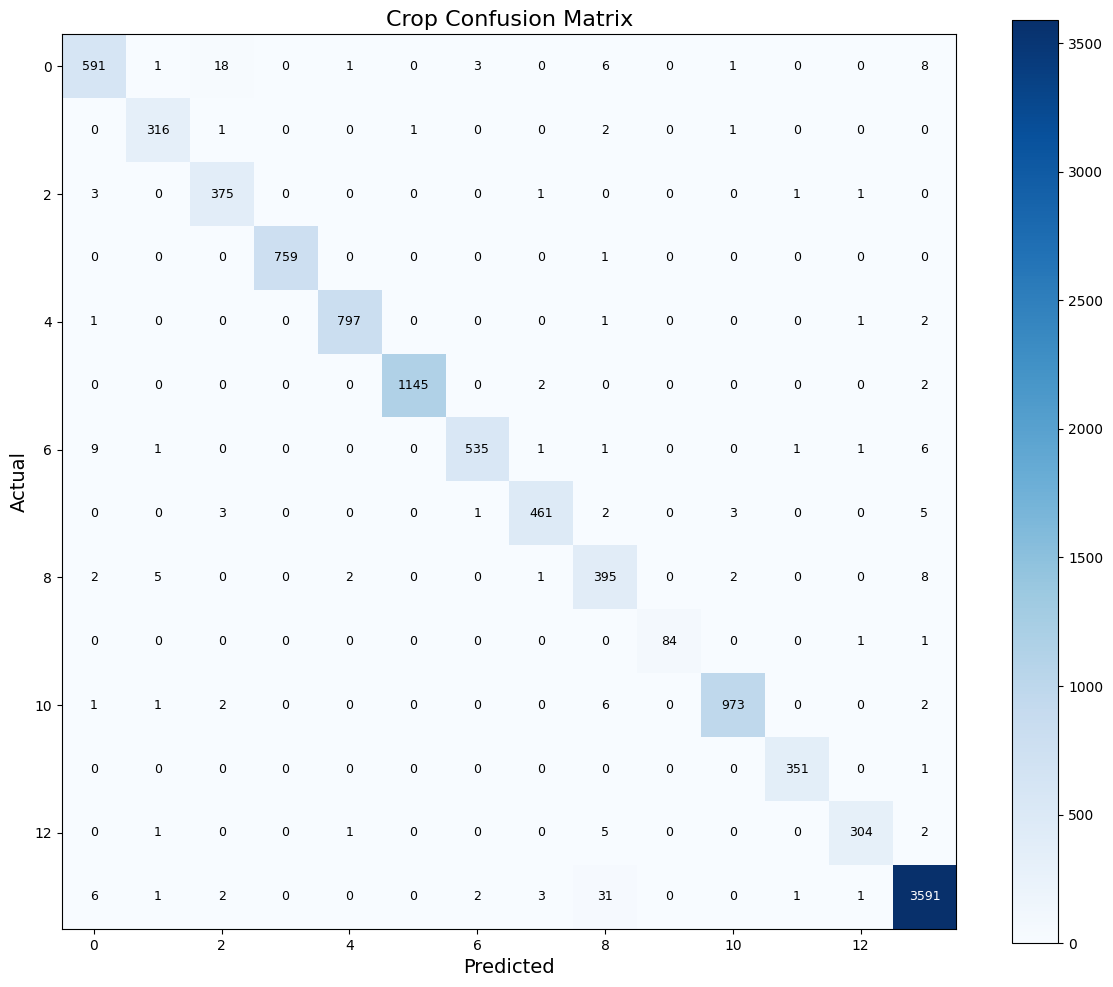

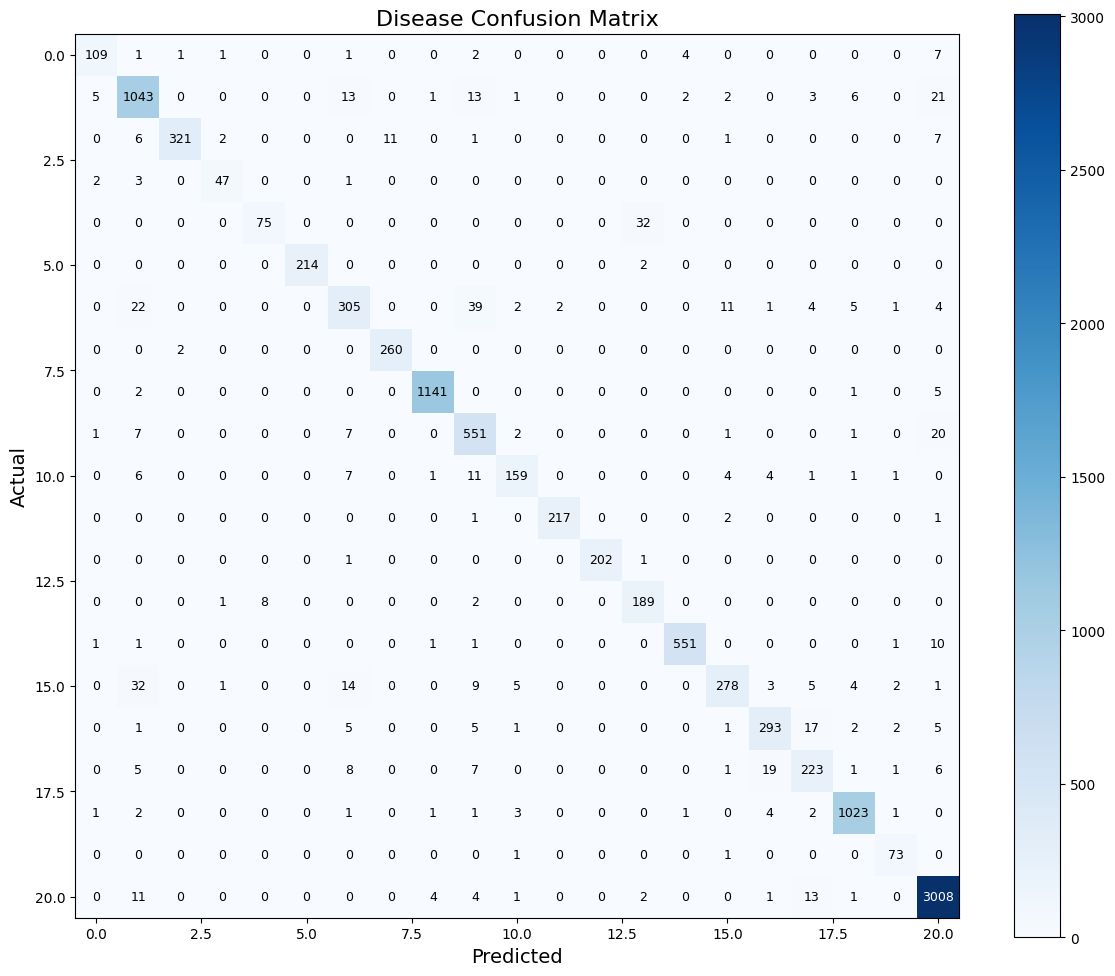

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cm(cm, title):
    plt.figure(figsize=(12,10))

    plt.imshow(cm, cmap='Blues')  # 🔥 light color
    plt.title(title, fontsize=16)
    plt.colorbar()

    plt.xlabel("Predicted", fontsize=14)
    plt.ylabel("Actual", fontsize=14)

    thresh = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=9,
                     color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()

plot_cm(cm_crop, "Crop Confusion Matrix")
plot_cm(cm_disease, "Disease Confusion Matrix")

In [18]:
from sklearn.metrics import classification_report

print("Crop Report:")
print(classification_report(y_crop_val, y_crop_pred))

print("Disease Report:")
print(classification_report(y_dis_val, y_disease_pred))

Crop Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       629
           1       0.97      0.98      0.98       321
           2       0.94      0.98      0.96       381
           3       1.00      1.00      1.00       760
           4       1.00      0.99      0.99       802
           5       1.00      1.00      1.00      1149
           6       0.99      0.96      0.98       555
           7       0.98      0.97      0.98       475
           8       0.88      0.95      0.91       415
           9       1.00      0.98      0.99        86
          10       0.99      0.99      0.99       985
          11       0.99      1.00      0.99       352
          12       0.98      0.97      0.98       313
          13       0.99      0.99      0.99      3638

    accuracy                           0.98     10861
   macro avg       0.98      0.98      0.98     10861
weighted avg       0.98      0.98      0.98     10861

Disease Repo

In [23]:
model.save("/content/drive/MyDrive/leaf_model.keras")

In [24]:
crop_names = crop_encoder.classes_
disease_names = disease_encoder.classes_

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cm(cm, classes, title):
    plt.figure(figsize=(14,12))  # bigger for labels

    plt.imshow(cm, cmap='Blues')
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(tick_marks, classes, rotation=90, fontsize=8)
    plt.yticks(tick_marks, classes, fontsize=8)

    plt.xlabel("Predicted", fontsize=14)
    plt.ylabel("Actual", fontsize=14)

    thresh = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=7,
                     color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()

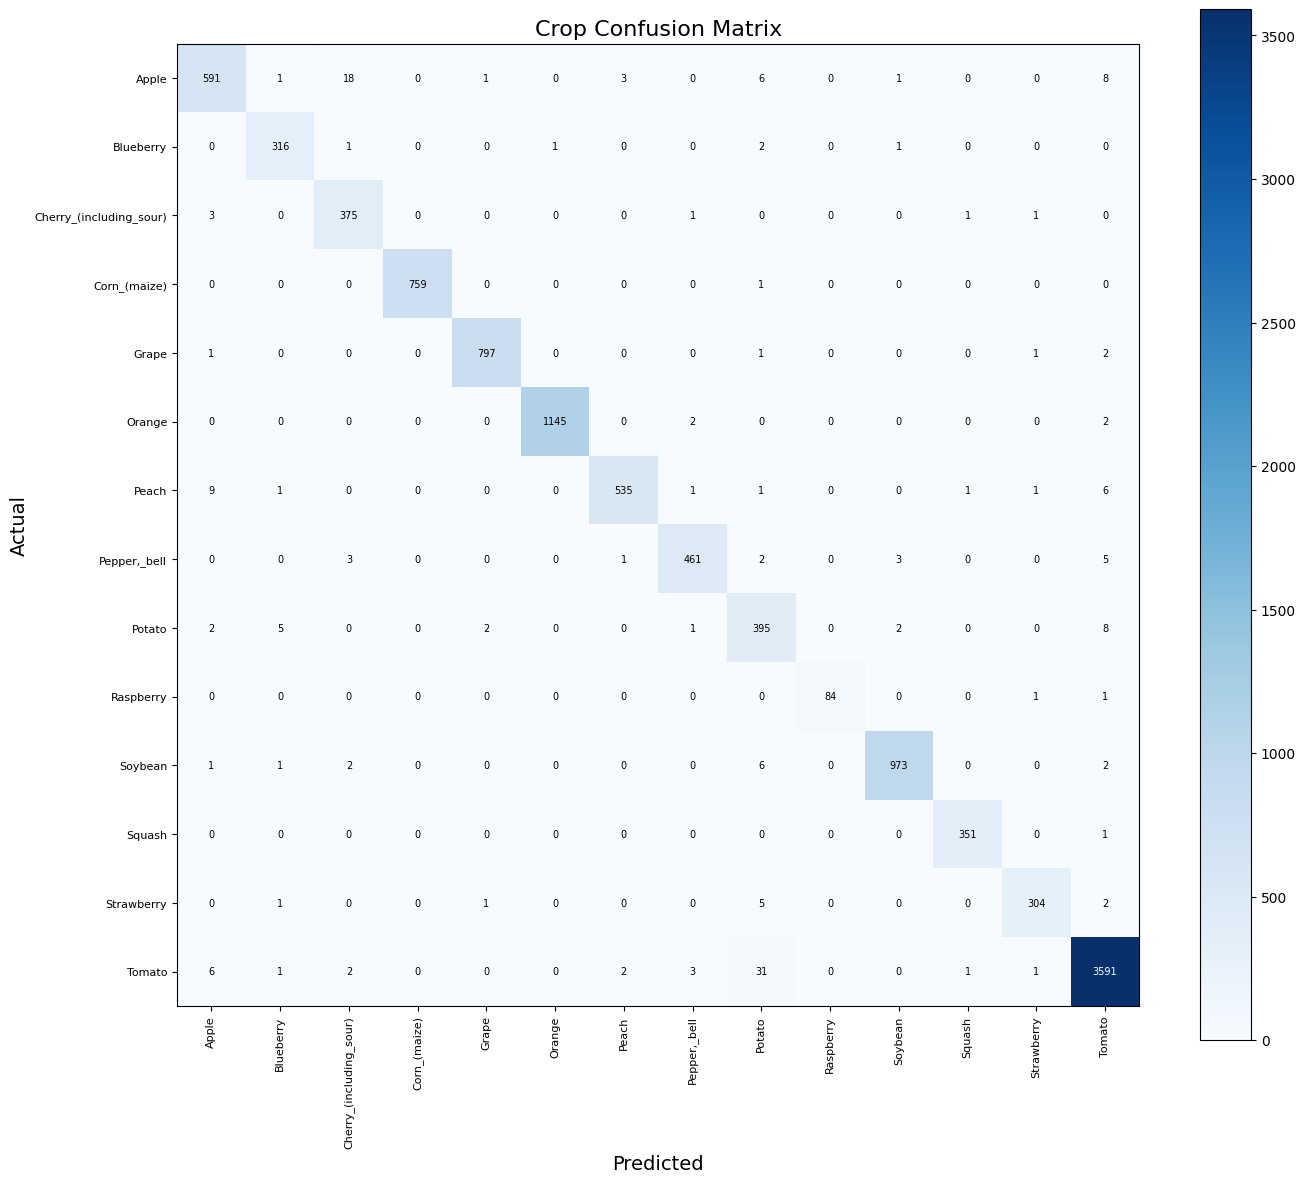

In [26]:
plot_cm(cm_crop, crop_names, "Crop Confusion Matrix")

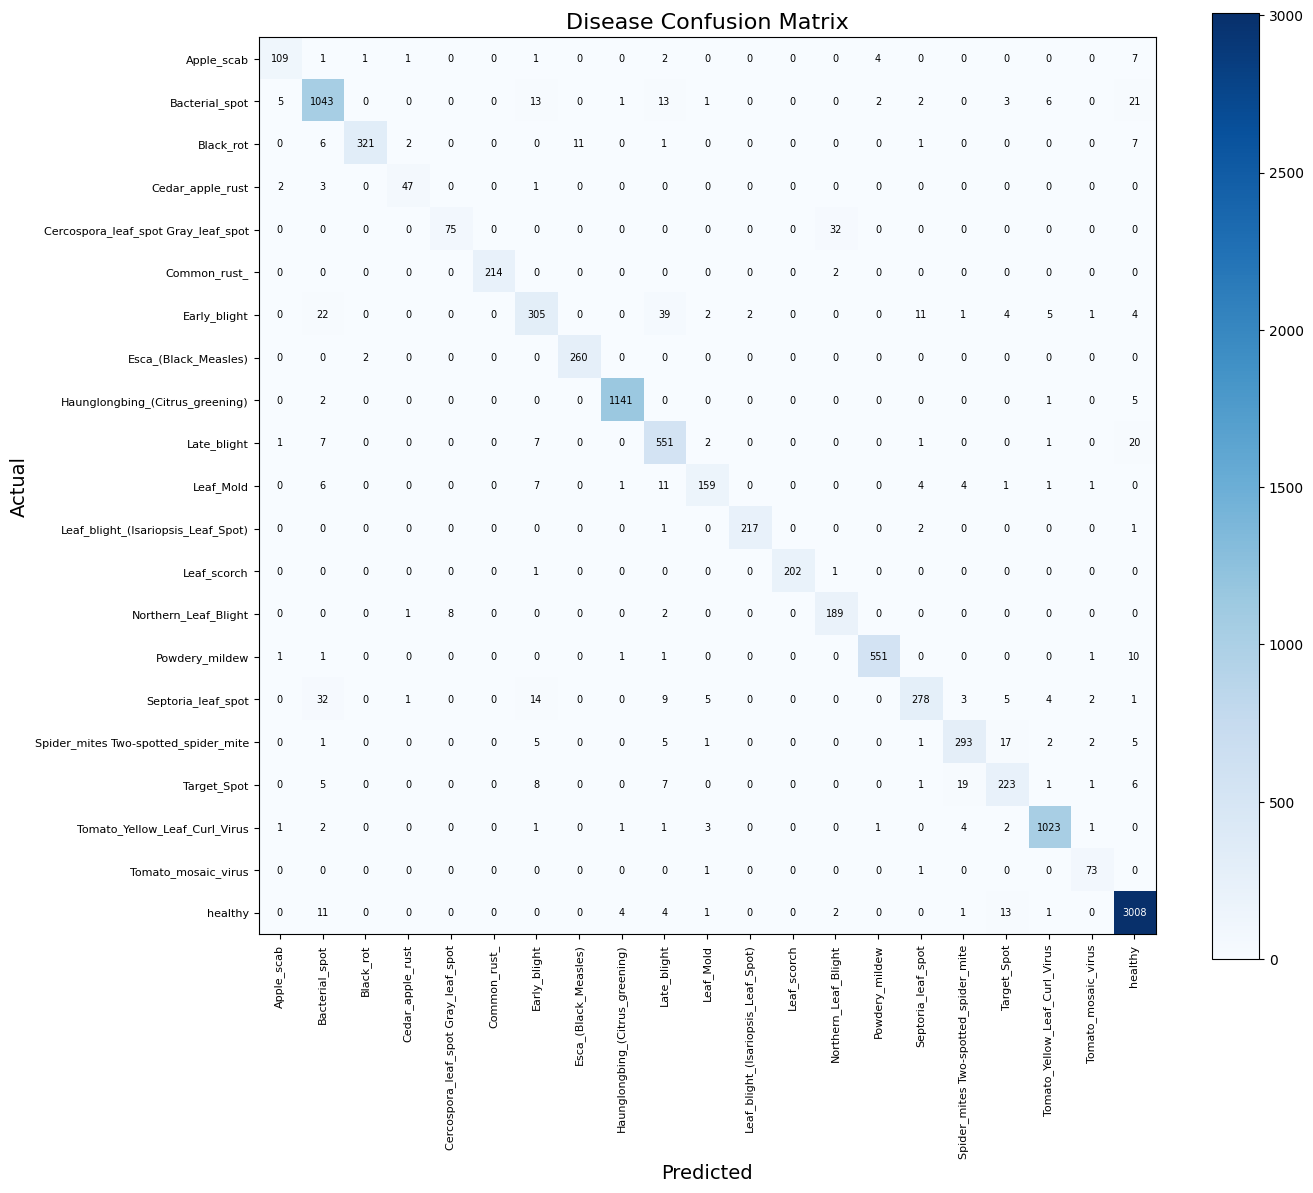

In [27]:
plot_cm(cm_disease, disease_names, "Disease Confusion Matrix")